# `kNNpy.kNN_2D_Ang` Tutorial: Clustering in the sky using 2D $k$-nearest neighbour distributions

# Part 3: Tracer-field cross-clustering

**Author**: Kaustubh Rajesh Gupta (email:[kaustubhrajeshgupta@swin.edu.au](mailto:kaustubhrajeshgupta@swin.edu.au))
\
**Date**: 28 June 2026\
**kNNpy version**: 0.0.1

#### This notebook presents a simple guide on how to use the `kNNpy.kNN_2D_Ang` module to compute the 2D tracer-field cross $k$NN distributions in angular coordinates for given data and interpret the results. The basic functionalities of the module are illustrated using realistic cosmological data. A detailed API [documentation](https://kitnenikatnivasi.github.io/kNNpy_documentation_html/kNNpy/kNN_2D_Ang.html) and source code for the module is available on the `kNNpy` [website](https://kitnenikatnivasi.github.io/).

<!--TABLE OF CONTENTS-->
## Contents:

- [Imports and setup](#Imports-and-setup)
- [Load mock galaxy data](#mock)
- [Vizualize the data](#Let's-vizualize-how-tracers-are-distributed-in-the-sky)
- [Compute the relevant spatial scales](#The-first-step-is-to-compute-the-relevant-spatial-scales-of-interest-at-which-the-$k$NN-distributions-can-be-computed.)
- [Construct the query points](#The-next-step-is-to-construct-the-query-points-from-which-the-nearest-neighbnour-distances-are-to-be-computed.)
- [Compute the $k$NN-CDFs](#cdf)
- [Plot the results](#let's-plot-the-results,-comparing-the-evaluated-CDFs-against-the-theoretical-expectation-for-unclustered-data:)
- [Interpretation of the CDFs](#Interpretation)
- [Thinking challenge](#Thinking-challenge)
- [Quantifying the clustering signal](#Quantifying-the-clustering-signal)
- [Computational Challenge](#Computational-Challenge)

## Imports and setup

#### Let's start by importing the required Python libraries. These should already be present in the `kNNpy_env` virtual environment created during the [installation](https://kitnenikatnivasi.github.io/install.html), so you should be able to import them without any issues.

In [1]:
#Importing external libraries

import numpy as np

import healpy as hp
from healpy.newvisufunc import projview

from matplotlib import pyplot as plt, ticker as mticker
import matplotlib.colors as colors

import copy

import os
import sys

import warnings

#We prefer turning off the annoying warnings thrown by Python. Comment out the line below if you prefer to view the warnings as they arise.
warnings.filterwarnings('ignore')

#Importing the kNNpy modules that will be used in this tutorial

#Necessary for relative imports (see https://stackoverflow.com/questions/34478398/import-local-function-from-a-module-housed-in-another-directory-with-relative-im)
module_path = os.path.abspath(os.path.join('../'))           # '../' is needed because the parent directory is one directories upstream of the tutorials directory
if module_path not in sys.path:
    sys.path.append(module_path)

from kNNpy import HelperFunctions as hf                 #some helper functions
from kNNpy import HelperFunctions_2DA as hf_2DA         #2D specifi helper functions
from kNNpy import kNN_2D_Ang                            #the main module
from kNNpy.Data import Datasets                         #helpful for retreiving example datasets

#### We define our `matplotlib` plotting preferences below; you can change them to your liking. Remember to set `ustex==False` if you do not have $\LaTeX$ installed. 

In [2]:
#Matplotlib settings

plt.rcParams['font.family'] = 'serif'
plt.rc('text', usetex=True)
plt.rcParams.update({'font.size': 18})
plt.rcParams["axes.linewidth"] = 2*0.8
plt.rcParams["xtick.direction"] = 'in'
plt.rcParams["xtick.major.width"] = 2*0.8
plt.rcParams["ytick.direction"] = 'in'
plt.rcParams["ytick.major.width"] = 2*0.8
plt.rcParams["xtick.major.size"] = 2*3.5
plt.rcParams["ytick.major.size"] = 2*3.5
plt.rcParams["xtick.minor.visible"] = True
plt.rcParams["ytick.minor.visible"] = True
plt.rcParams["xtick.minor.width"] = 2*0.6
plt.rcParams["ytick.minor.width"] = 2*0.6
plt.rcParams["xtick.minor.size"] = 2*2
plt.rcParams["ytick.minor.size"] = 2*2

DefaultColorCycle = plt.rcParams['axes.prop_cycle'].by_key()['color']
BrightColors = ['cyan', 'yellow', 'lime', 'pink', '#E0B0FF']

## Main

#### <a name="mock" id="mock"></a> In this tutorial, we illustrate how to use `kNNpy` to quantify 2D tracer-field cross-correlations with the $k$-nearest neighbour distributions. For this purpose, we use forecasts for [Rubin Observatory's](https://www.lsst.org/) LSST y1 galaxy overdensity field created using the publicly available [AGORA lightcone simulations](https://yomori.github.io/agora/index.html).

#### Let's plot the skymap of the forecast LSST y1 galaxy overdensity field:

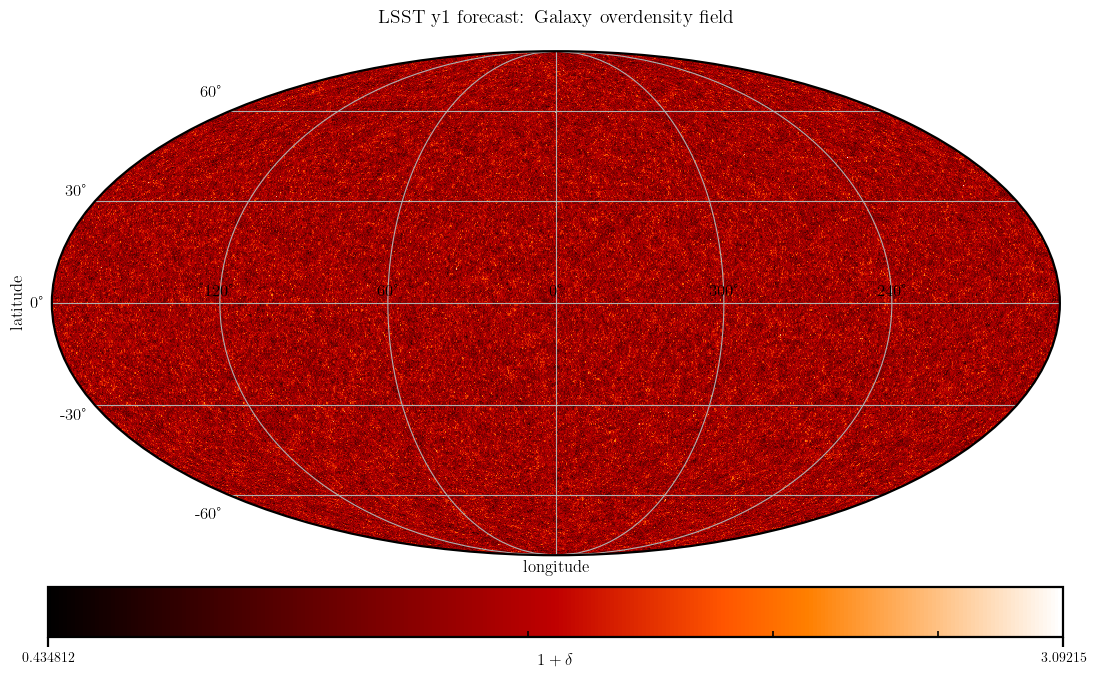

In [9]:
#Plotting the galaxy overdensity map

fig = plt.figure(figsize=(18, 7))
ax1= plt.subplot(1, 1, 1)

plt.axes(ax1)
projview(
    1.+delta_gal_masked,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit=r'$1+\delta$',
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=30,
    projection_type="mollweide",
    title=f"LSST y1 forecast: Galaxy overdensity field\n",
    cmap='gist_heat',
    norm="log", 
    flip="astro",
    min=1+delta_gal_masked[(delta_gal_masked!=hp.UNSEEN)&(delta_gal_masked!=-1)].min(),
    max=1+delta_gal_masked[delta_gal_masked!=hp.UNSEEN].max(),
    hold=True,
    sub=111
)

plt.show()
plt.close()

#### A key research question in cosmology is whether Merging Binary Black Holes (BBHs) are trace fluctuations in the matter overdensity field of the universe. If BBHs preferentially merge inside galaxies, they are expected to be spatially correlated with the galaxy field. 

#### Let's assume the above hypothesis is true, and create 10 realisations of 28,000 mock BBHs by Poisson-sampling the forecast LSST galaxy overdensity field. We will use this data set as the 'discrete tracers', and quantify their cross-correlation with the galaxy density field using the nearest-neightbour distributions. 

#### Additionally, let's also create 10 realisations of 28,000 randomly-distributed tracers. This unclustered sample is expected to be uncorrelated with the galaxy overdensity field, and therefore serves as the control data set.

In [3]:
#Setting the NSIDE for the galaxy overdensity field
NSIDE = 512

#Number of realisations
n_reals = 10

#Number of tracers in each realisations
n_tracer = 28_000

#Setting a trivial mask to indicate a complete sky coverage
mask = np.ones(12*NSIDE**2)
mask[mask!=1] = hp.UNSEEN

In [4]:
#Loading the forecast LSST y1 galaxy overdensity field, indicating that we do not want to use the forecast observational footprint
delta_gal_masked = Datasets.Load_forecast_LSSTy1_galaxy_field(masked=False, NSIDE=NSIDE)

#Creating multiple realisations of merging Binary Black Holes, assuming they are unbiased tracers of the LSST galaxy density field
bbh_pos_masked_ds_arr, bbh_map = Datasets.Sample2DTracersFromField(delta_sampling=delta_gal_masked, mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

#Creating the same number of realisations of randoms on the sky to serve as the control
randoms_pos_masked_ds_arr, randoms_map = Datasets.Sample2DPoissonTracers(mask=mask, N_realisations=n_reals, n_tracers=n_tracer, seed=None, map_NSIDE=64)

#### Let's vizualize how the mock BBHs and the randoms are distributed in the sky

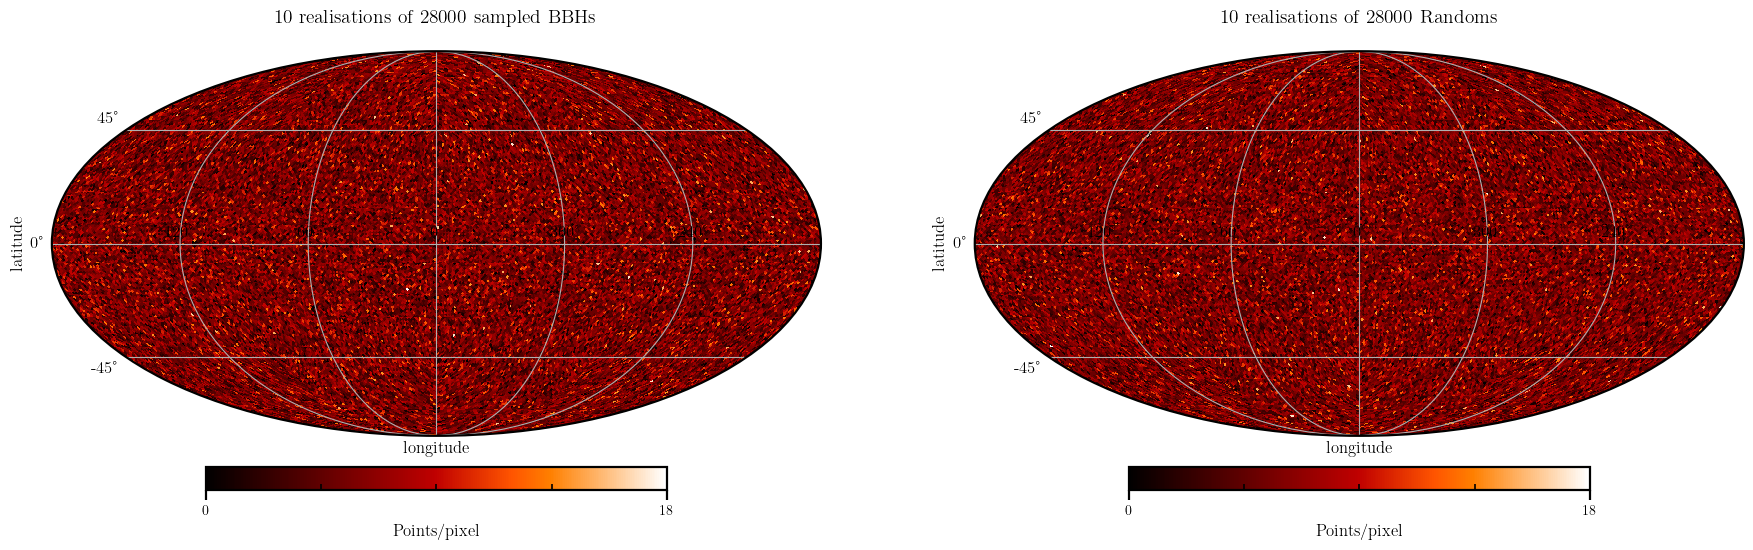

In [10]:
#Plotting the sampled tracers and randoms

fig = plt.figure(figsize=(18, 7))
ax1, ax2 = plt.subplot(1, 2, 1), plt.subplot(1, 2, 2)

plt.axes(ax1)
projview(
    bbh_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_tracer} sampled BBHs\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    # min=map_gal[mask!=hp.UNSEEN].min(),
    # max=map_gal[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=121
)

plt.axes(ax2)
projview(
    randoms_map,
    coord=["C"],
    graticule=True,
    graticule_labels=True,
    unit="\nPoints/pixel",
    xlabel="longitude",
    ylabel="latitude",
    cbar=True,
    cb_orientation="horizontal",
    latitude_grid_spacing=45,
    projection_type="mollweide",
    title=f"{n_reals} realisations of {n_tracer} Randoms\n",
    cmap='gist_heat',
    norm="linear", 
    flip="astro",
    # min=map_1[mask!=hp.UNSEEN].min(),
    # max=map_1[mask!=hp.UNSEEN].max(),
    hold=True,
    sub=122
)

plt.show()
plt.close()

Note how in this case, it is not obvious from the skymaps whether the tracers are more clustered than the randoms

#### As in the previous tutorials, the first step is to compute the relevant spatial scales of interest at which the $k$NN distributions can be computed. This is dictated by the number density of the sampled tracers, and is computed in a similar way as the previous tutorials:

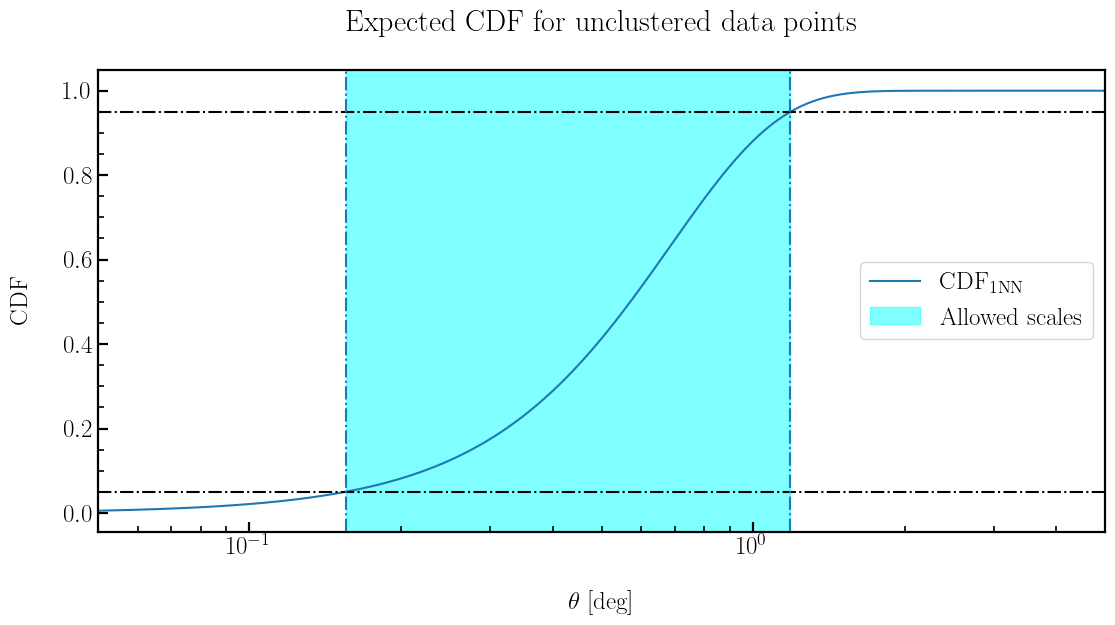

Relevant angular distance scales (deg):

	1NN:	 0.16 1.19
	2NN:	 0.41 1.49
	4NN:	 0.80 1.91


In [11]:
#Defining which neighbours to use
k_List = [1, 2, 4]

#Getting the tracer number density
n_bar_red = (bbh_pos_masked_ds_arr.shape[1]/(4*np.pi))*(12*NSIDE**2/len(np.where(mask!=hp.UNSEEN)[0]))

#Computing the analytical value of the kNN-CDFs for unclustered data on a wide range of angular scales

bins = np.zeros((len(k_List), 10000))
for i, k in enumerate(k_List):
    bins[i] = np.deg2rad(np.geomspace(0.05, 10, 10000))

Theoretical_Uniform_CDFs_test = []
for i, k in enumerate(k_List):
    Theoretical_Uniform_CDFs_test.append(hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(bins[i])), n_bar_red, k))

#Selecting 10 log-spaced bins where the kNN-CDFs are expected to be between 0.05 and 0.95

low_bin = np.zeros(len(k_List)).astype(int)
high_bin = np.zeros(len(k_List)).astype(int)

for i, k in enumerate(k_List):
    low_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.05)
    high_bin[i] = np.searchsorted(Theoretical_Uniform_CDFs_test[i], 0.95)

sel_bins = np.zeros((len(k_List), 10))
for i, k in enumerate(k_List):
    sel_bins[i] = np.geomspace(bins[i][low_bin[i]]*0.95, bins[i][high_bin[i]]*1.05, 10)

th_uni_arr = np.zeros((len(k_List), sel_bins.shape[1]))
for i, k in enumerate(k_List):
    th_uni_arr[i] = hf_2DA.PoissonUniformCDFs(2*np.pi*(1-np.cos(sel_bins[i])), n_bar_red, k)

#Let's plot the expected 1NN-CDF for the unclustered data
plt.figure(figsize=(13,6))
i=0    #change the value of i and k to plot a different kNN-CDF
k=1
plt.plot(np.rad2deg(bins[i]), Theoretical_Uniform_CDFs_test[i], label='CDF$_{{\\rm {}NN}}$'.format(k))
plt.axhline(0.05, ls='-.', c='k')
plt.axhline(0.95, ls='-.', c='k')
plt.axvline(np.rad2deg(bins[i][low_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvline(np.rad2deg(bins[i][high_bin[i]]), ls='-.', c=DefaultColorCycle[i])
plt.axvspan(np.rad2deg(bins[i][low_bin[i]]), np.rad2deg(bins[i][high_bin[i]]), alpha=0.5, color=BrightColors[i], label=f'Allowed scales')
plt.xlim([0.05, 5])
plt.title('Expected CDF for unclustered data points\n')
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('CDF\n')
plt.xscale('log')
# plt.yscale('log')
plt.legend()
plt.show()
plt.close()

#Print out the scales
print('Relevant angular distance scales (deg):\n')
for i, k in enumerate(k_List):
    print(f'\t{k}NN:\t', '{:.2f}'.format(np.rad2deg(bins[i][low_bin[i]])), '{:.2f}'.format(np.rad2deg(bins[i][high_bin[i]])))
# Uncomment lines below to print out the exact scales sampled
# for i, k in enumerate(k_List):
#     print(f'\nAngular distance bins for {k}NN-CDF: \n\n', np.rad2deg(sel_bins[i]))
#     print(f'\nNumber of bins for {k}NN-CDF: ', len(sel_bins[i]))

#### The next step is to construct the query points from which the nearest-neighbour distances are to be computed:

In [12]:
#Generate the query positions
query_mask, query_pos = hf_2DA.create_query_2DA(NSIDE, mask)

#### Finally, we need to set a threshold overdensity (dt) for the continuous field. 

The probability of the field smoothed at a given angular scale exceeding this threshold serves as a measure of the intrinsic clustering of the continuous field, similar to the role played by the $k$NN-CDFs for discrete tracers (see [Banerjee & Abel (2023)](https://academic.oup.com/mnras/article/519/4/4856/6965833) for discussion). 

#### For now, let's set it to the $75^{\rm th}$ percentile of the overdensity map (dt=75), such that the probability of the field exceeding this value is equal to 0.75 at all distance scales. Feel free to play around with this parameter later (note that currently, `kNNpy` only supports a constant percentile density threshold).

In [14]:
delta_threshold = 75.0

#### <a name="cdf" id="cdf"></a> Now, we are ready to measure the tracer-field cross-clustering for our mock datasets. Let's use the `TracerFieldCross2DA()` method to compute the nearest-neighbour distributions for a single realisation of the BBHs and the randoms. 

#### The quantities being computed are:
1. the auto-CDFs for the discrete tracers $\mathcal{P}_{\geq k}$,
2. the continuum limit of the autoCDFs for the continuous field $\mathcal{{P}}_{{>dt}}$, and
3. and the tracer-field cross-CDFs $\mathcal{P}_{\geq k, >dt}$,

#### as defined in 3D by [Banerjee & Abel (2023)](https://academic.oup.com/mnras/article/519/4/4856/6965833) and generalized to 2D angular coordinates by [Gupta & Banerjee (2024)](https://academic.oup.com/mnras/article/531/4/4619/7690170)

In [15]:
#Print the API documentation for details on the function usage
help(kNN_2D_Ang.TracerFieldCross2DA)

Help on function TracerFieldCross2DA in module kNNpy.kNN_2D_Ang:

TracerFieldCross2DA(kList, BinsRad, MaskedQueryPosRad, MaskedTracerPosRad, FieldSkymap, QueryMask, FieldConstPercThreshold, ReturnSmoothedDict=False, Verbose=False)
    Returns the probabilities $P_{\geq k}$, $P_{>{\rm dt}}$ and $P_{\geq k,>{\rm dt}}$ for $k$ in `kList`, that quantify the extent of the spatial cross-correlation between the given discrete tracer positions (`MaskedTracerPosRad`) and the given continuous overdensity field (`FieldSkymap`).

    1. $P_{\geq k}(\theta)$:
        the kNN-CDF of the discrete tracers, evaluated at angular distance scale $\theta$

    2. $P_{>{\rm dt}}(\theta)$:
        the probability of the overdensity field smoothed with a top-hat filter of angular size $\theta$ exceeding the given constant percentile density threshold

    3. $P_{\geq k, >{\rm dt}}(\theta)$:
        the joint probability of finding at least 'k' tracers within a spherical cap of radius $\theta$ AND the overdens

In [16]:
randomxgalaxy_kNN_results = kNN_2D_Ang.TracerFieldCross2DA(k_List, sel_bins, query_pos, randoms_pos_masked_ds_arr[0], delta_gal_masked, query_mask, delta_threshold, ReturnSmoothedDict=False, Verbose=True)

random_autoCDFs = randomxgalaxy_kNN_results[0]    #The auto-CDFs for the randoms
random_pdt = randomxgalaxy_kNN_results[1]         #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
random_jointCDFs = randomxgalaxy_kNN_results[2]   #The randoms-field cross-CDF

dataxgalaxy_kNN_results = kNN_2D_Ang.TracerFieldCross2DA(k_List, sel_bins, query_pos, bbh_pos_masked_ds_arr[0], delta_gal_masked, query_mask, delta_threshold, ReturnSmoothedDict=False, Verbose=True)

data_autoCDFs = dataxgalaxy_kNN_results[0]        #The auto-CDFs for the BBHs
data_pdt = dataxgalaxy_kNN_results[1]             #The intrinsic clustering of the field; is equal to 0.75 at all distance scales for our case 
data_jointCDFs = dataxgalaxy_kNN_results[2]       #The BBH-field cross-CDF


Checking inputs ...
	done.

initiating step 1 (NN measurements for the discrete tracer set)...

	building the tree ...
		done; time taken: 1.57e-02 s.

	computing the tracer NN distances ...
		done; time taken: 1.30e+01 s.

	computing the tracer auto-CDFs P_{>=k} ...
		done; time taken: 8.51e-01 s.

time taken for step 1: 1.39e+01 s.

initiating step 2 (smoothing the continuous field at the given angular distance scales)...
	done; time taken for step 2: 1.69e+01 s.

initiating step 3 (computing the tracer-field cross-correlation)...

	Computing P_(>dt) and P_(>=k, >dt) for k = 1 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 2 ...
	Computing P_(>dt) and P_(>=k, >dt) for k = 4 ...

	done; time taken for step 3: 5.86e-01 s.

total time taken: 3.14e+01 s.
Checking inputs ...
	done.

initiating step 1 (NN measurements for the discrete tracer set)...

	building the tree ...
		done; time taken: 5.48e-03 s.

	computing the tracer NN distances ...
		done; time taken: 1.35e+01 s.

	computing t

#### let's plot the results

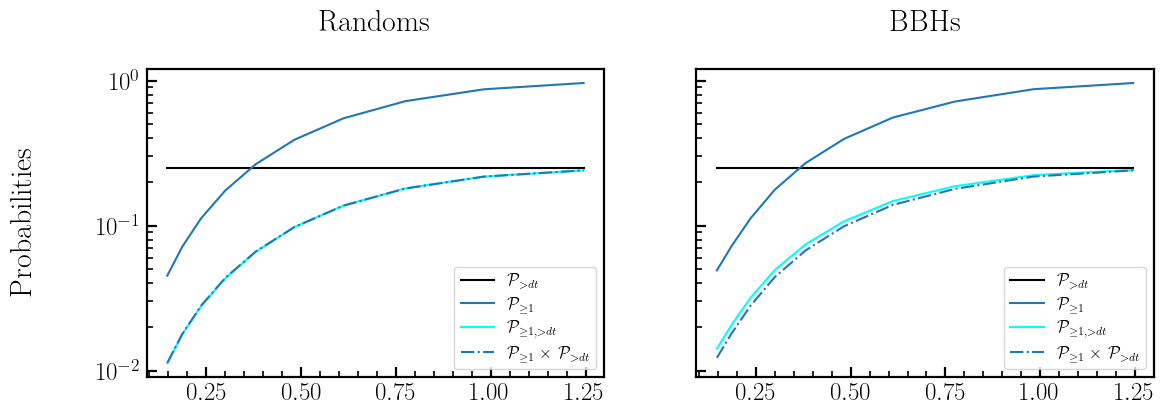

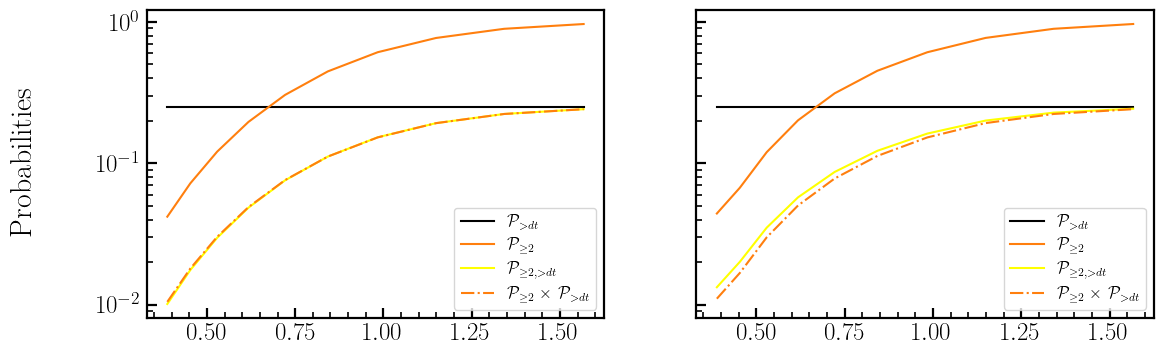

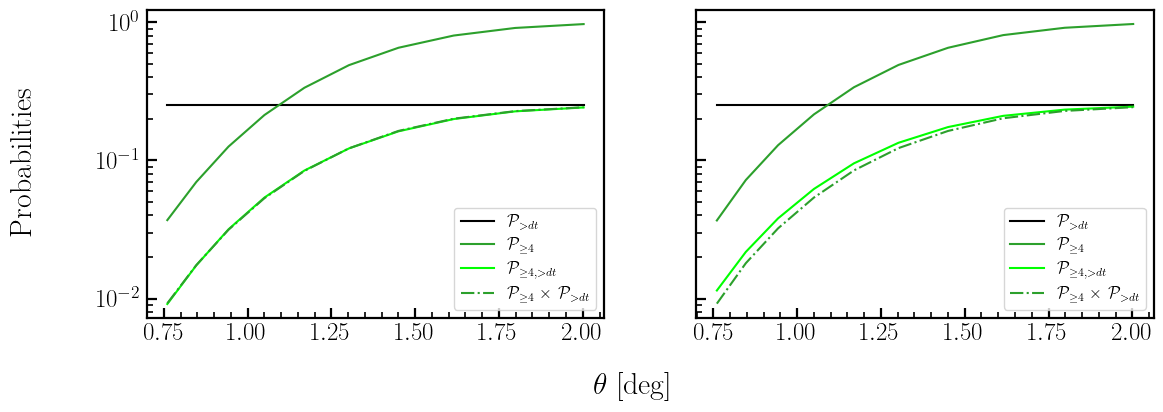

In [20]:
for i, k in enumerate(k_List):

    fig, (ax, ax1) = plt.subplots(1, 2, figsize=(13, 4), sharex=True, sharey=True)
    
    ax.plot(np.rad2deg(sel_bins[i]), random_pdt[i], c='k', label='$\\mathcal{{P}}_{{>dt}}$')
    ax.plot(np.rad2deg(sel_bins[i]), random_autoCDFs[i], c=DefaultColorCycle[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax.plot(np.rad2deg(sel_bins[i]), random_jointCDFs[i], c=BrightColors[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax.plot(np.rad2deg(sel_bins[i]), random_autoCDFs[i]*random_pdt[i], c=DefaultColorCycle[i], ls='-.', label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax.legend(fontsize=12)
    if i==0: ax.set_title('Randoms\n')
    
    ax1.plot(np.rad2deg(sel_bins[i]), data_pdt[i], c='k', label='$\\mathcal{{P}}_{{>dt}}$')
    ax1.plot(np.rad2deg(sel_bins[i]), data_autoCDFs[i], c=DefaultColorCycle[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$'.format(k))
    ax1.plot(np.rad2deg(sel_bins[i]), data_jointCDFs[i], c=BrightColors[i], label='$\\mathcal{{P}}_{{\\geq {:.0f}, >dt}}$'.format(k))
    ax1.plot(np.rad2deg(sel_bins[i]), data_autoCDFs[i]*data_pdt[i], c=DefaultColorCycle[i], ls='-.', label='$\\mathcal{{P}}_{{\\geq {:.0f}}}$ $\\times$ $\\mathcal{{P}}_{{>dt}}$'.format(k))
    ax1.legend(fontsize=12)
    if i==0: ax1.set_title('BBHs\n')

    if i==len(k_List)-1: fig.supxlabel(r'$\theta$ [deg]', y=-0.1)
    fig.supylabel('Probabilities')

    plt.yscale('log')
    plt.show()
    plt.close()

#### Interpretation

\<Need to write\>

#### To make it easier to vizualize the clustering signal, we can compute a quantity known as the excess cross-correlation, which is defined as
$\psi_{k, dt} = \frac{\mathcal{P}_{\geq k, >dt}}{\mathcal{P}_{\geq k}\times\mathcal{{P}}_{{>dt}}}$

#### An excess cross-correlation of greater (lesser) than 1 implies that the tracers are positively (negatively) correlated with the field, while a unity value indicates that the tracers are uncorrelated with the field.

In [26]:
randoms_psi = hf.kNN_excess_cross_corr(random_autoCDFs, random_pdt, random_jointCDFs, k1_k2_list=None)
data_psi = hf.kNN_excess_cross_corr(data_autoCDFs, data_pdt, data_jointCDFs, k1_k2_list=None)

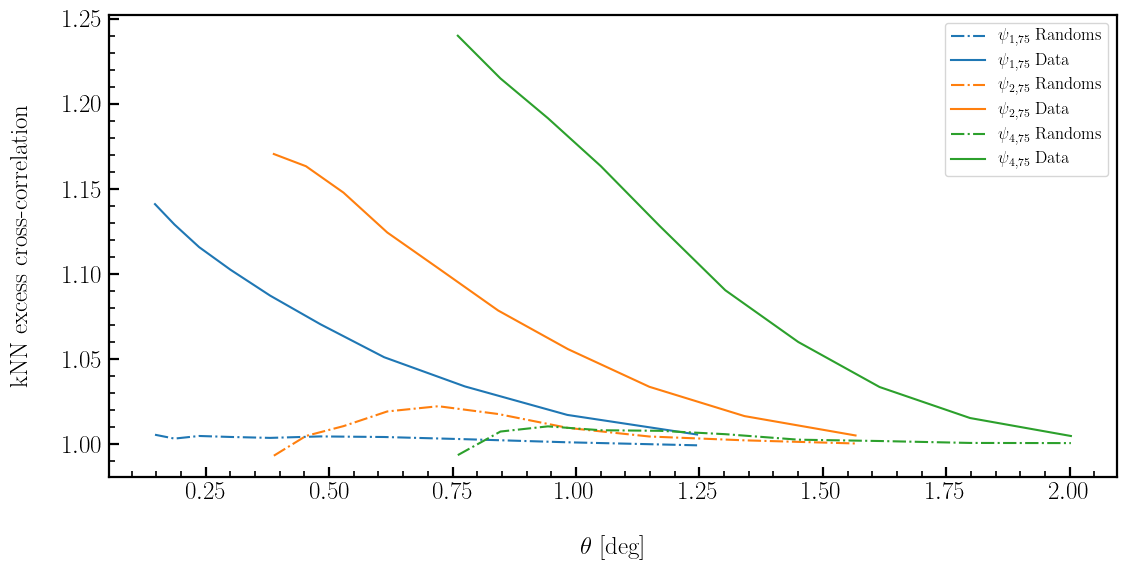

In [27]:
plt.figure(figsize=(13, 6))

for i, k in enumerate(k_List):
    plt.plot(np.rad2deg(sel_bins[i]), randoms_psi[i], c=DefaultColorCycle[i], ls='-.', label='$\\psi_{{{:.0f}, {:.0f}}}$ Randoms'.format(k, delta_threshold))
    plt.plot(np.rad2deg(sel_bins[i]), data_psi[i], c=DefaultColorCycle[i], label='$\\psi_{{{:.0f}, {:.0f}}}$ Data'.format(k, delta_threshold))
        
plt.xlabel('\n$\\theta$ [deg]')
plt.ylabel('kNN excess cross-correlation\n')
plt.legend(fontsize=12)
plt.show()
plt.close()

#### We see that the mock BBHs indeed appear correlated with the field, as expected, while the randoms appear uncorrelated.